In [ ]:
import joblib
import pandas as pd
import shap

# Load pipeline
fe = joblib.load("feature_engineering.pkl")
features = joblib.load("features.pkl")
model = joblib.load("multi_output_xgb_model.pkl")

# Load training data for SHAP background
train_unscaled = pd.read_csv("train_unscaled_processed.csv")
target_cols = ["Fatigue","FutureHealthRisk","DiabetesRisk","AnemiaRisk","PCOSRisk"]
X_train = train_unscaled.drop(columns=target_cols)

# Create one explainer per output (cache these!)
explainers = []
for i in range(len(target_cols)):
    explainers.append(shap.Explainer(model.estimators_[i], X_train))

example

In [ ]:
def predict_and_explain(user_input_dict):
    # --- preprocess ---
    df = pd.DataFrame([user_input_dict])
    df = fe(df)
    df = df[features]

    # --- predict (multi-output) ---
    preds = model.predict(df)[0]  # array of 5 outputs

    # --- explain each output ---
    explanations = {}

    for i, col in enumerate(target_cols):
        explainer = explainers[i]
        sv = explainer(df)  # shap values for this sample

        # pick predicted class for this output
        pred_class = int(preds[i])

        # shap values for (sample, features, class)
        vals = sv.values[0, :, pred_class]
        feature_names = df.columns

        # top 3 contributors (by absolute impact)
        import numpy as np
        idx = np.argsort(np.abs(vals))[::-1][:3]

        top_features = [
            (feature_names[j], float(vals[j]))
            for j in idx
        ]

        explanations[col] = {
            "prediction": int(pred_class),
            "top_features": top_features
        }

    return explanations

In [ ]:
def explain_to_text(explanations):
    label_map = {0: "Low", 1: "Medium", 2: "High"}
    output = {}

    for target, info in explanations.items():
        pred_label = label_map[info["prediction"]]

        reasons = []
        for feat, val in info["top_features"]:
            if val > 0:
                reasons.append(f"{feat} increased risk")
            else:
                reasons.append(f"{feat} reduced risk")

        output[target] = {
            "Prediction": pred_label,
            "Reasons": reasons
        }

    return output

In [ ]:
def generate_recommendations(df_row):
    recs = []

    if df_row["SleepScore"].values[0] < 0.6:
        recs.append("Improve sleep to 7–8 hours")

    if df_row["StressScore"].values[0] > 0.7:
        recs.append("Practice stress management (meditation/exercise)")

    if df_row["SedentaryIndex"].values[0] > 0.6:
        recs.append("Increase daily physical activity")

    if df_row["DigitalLoad"].values[0] > 6:
        recs.append("Reduce screen time, especially at night")

    return recs

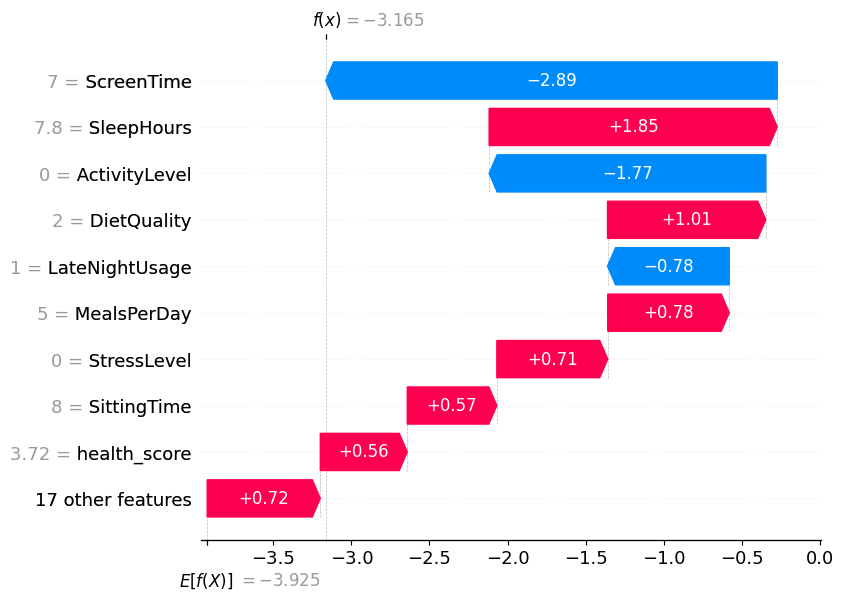

In [8]:
shap.plots.waterfall(shap_values[0, :, 0])

In [9]:
pred = fatigue_model.predict(sample)
print(pred)

[1]


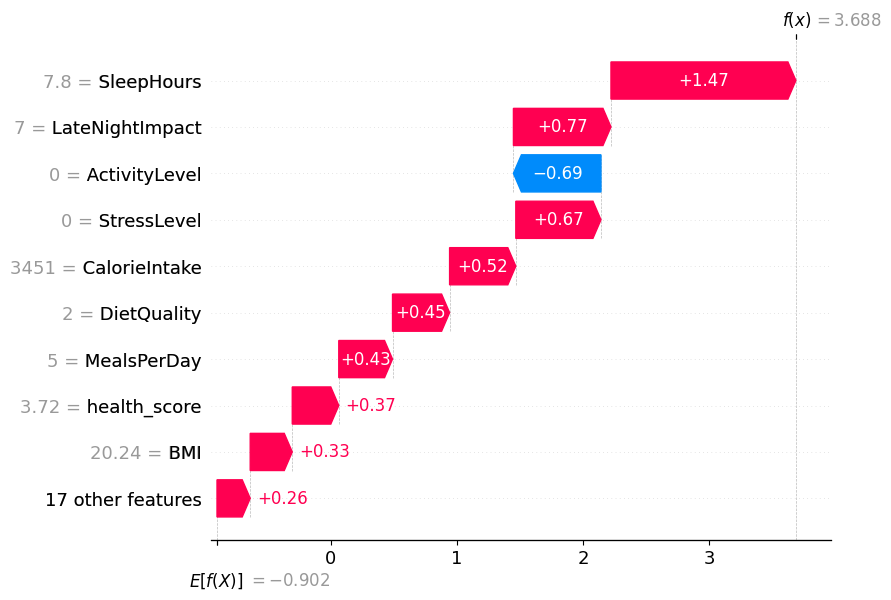

In [10]:
shap.plots.waterfall(shap_values[0, :, pred[0]])